In [69]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

In [70]:
#
data = yf.Ticker("AAPL") #creates ticker object for apple stocks everything will be referencing this object
data.info # returns a large dict of general comp info: market cap, sector, P/E ratio, 52-week high/low
data.calendar #returns upcoming events like earnings dates and expected EPS ranges
data.analyst_price_targets #retunrs analyst consensus price targets(low, mean, high, current)
data.quarterly_income_stmt #returns the last few quarters of income statement data: rev, gross profit, net income
data.history(period='1mo') # returns a df of daily OHLCV price data for the past 1 month
data.option_chain(data.options[0]).calls # gets the nearest exp dat from the list of options  and fetches 
# the options chain for the date and reutnrs just the call contracts 


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260513C00205000,2026-05-11 16:19:58+00:00,205.0,86.95,0.0,0.0,0.0,0.0,2,NaN,0.000010,True,REGULAR,USD
1,AAPL260513C00230000,2026-05-11 19:18:25+00:00,230.0,61.48,0.0,0.0,0.0,0.0,2,0.0,0.000010,True,REGULAR,USD
2,AAPL260513C00245000,2026-05-11 17:15:20+00:00,245.0,46.51,0.0,0.0,0.0,0.0,130,0.0,0.000010,True,REGULAR,USD
3,AAPL260513C00250000,2026-05-11 15:28:33+00:00,250.0,43.38,0.0,0.0,0.0,0.0,1,0.0,0.000010,True,REGULAR,USD
4,AAPL260513C00255000,2026-05-11 19:12:24+00:00,255.0,36.66,0.0,0.0,0.0,0.0,2,0.0,0.000010,True,REGULAR,USD
5,AAPL260513C00257500,2026-05-08 19:40:59+00:00,257.5,35.40,0.0,0.0,0.0,0.0,10,0.0,0.000010,True,REGULAR,USD
6,AAPL260513C00260000,2026-05-11 19:18:25+00:00,260.0,31.59,0.0,0.0,0.0,0.0,1,0.0,0.000010,True,REGULAR,USD
7,AAPL260513C00265000,2026-05-08 13:43:18+00:00,265.0,28.00,0.0,0.0,0.0,0.0,1,0.0,0.000010,True,REGULAR,USD
8,AAPL260513C00267500,2026-05-07 14:19:36+00:00,267.5,22.99,0.0,0.0,0.0,0.0,1,0.0,0.000010,True,REGULAR,USD
9,AAPL260513C00270000,2026-05-11 17:27:59+00:00,270.0,21.89,0.0,0.0,0.0,0.0,219,0.0,0.000010,True,REGULAR,USD


## Simple Moving Average (SMA)

The SMA averages the closing price over the past $n$ days with equal weight:

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

where $P_t$ is the closing price at time $t$ and $n$ is the window size. The first $n-1$ values are undefined ($\text{NaN}$) since there are not enough prior observations to fill the window.

---

## Exponential Moving Average (EMA)

The EMA applies exponentially decaying weights so that recent prices matter more:

$$\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$$

where the smoothing factor $\alpha$ is:

$$\alpha = \frac{2}{n + 1}$$

As prices get older, the weight $(1-\alpha)^i$ shrinks toward zero — recent prices dominate. Unlike SMA, EMA produces no $\text{NaN}$ gap at the start since it is computed recursively from the first observation.

---

## Why Calculate SMA and EMA?

**Trend Identification**
- Price above SMA/EMA → uptrend; price below → downtrend
- Smooths out day-to-day noise so the broader direction is clearer

**Signal Generation (Crossovers)**
- When a short-term MA crosses above a long-term MA → *golden cross* (bullish signal)
- When it crosses below → *death cross* (bearish signal)

**ML Feature Engineering**
- Raw price is non-stationary (trends upward over time), which hurts model performance
- SMA and EMA give the model a sense of where price has been trending, capturing momentum without overfitting to raw price levels

**EMA vs SMA**
- EMA reacts faster to recent price changes, making it more useful for short-term prediction
- SMA is smoother and better for identifying long-term trends

In [71]:
#simple moving average (30-days)
history = data.history(period='1y')
history['SMA30'] = history['Close'].rolling(window=30).mean() 

#exponential moving average (50 days)
history['EMA50'] = history['Close'].ewm(span=50, adjust=False).mean()

print(history[['Close','SMA30','EMA50']])

                                Close       SMA30       EMA50
Date                                                         
2025-05-12 00:00:00-04:00  209.957062         NaN  209.957062
2025-05-13 00:00:00-04:00  212.088593         NaN  210.040651
2025-05-14 00:00:00-04:00  211.490967         NaN  210.097526
2025-05-15 00:00:00-04:00  210.614456         NaN  210.117798
2025-05-16 00:00:00-04:00  210.425186         NaN  210.129853
...                               ...         ...         ...
2026-05-05 00:00:00-04:00  283.918427  263.294419  264.629793
2026-05-06 00:00:00-04:00  287.245361  264.488985  265.516678
2026-05-07 00:00:00-04:00  287.175415  265.648583  266.366040
2026-05-08 00:00:00-04:00  293.050018  266.995010  267.412471
2026-05-11 00:00:00-04:00  292.679993  268.465310  268.403354

[251 rows x 3 columns]


## Lagged Returns

---

A **lagged return** is a time-shifted copy of the returns column. Each lag represents what the return was $n$ days ago:

- **Lag1** — yesterday's return $(t-1)$
- **Lag2** — two days ago $(t-2)$
- **Lag3** — three days ago $(t-3)$

Lags turn a time series prediction problem into a standard regression problem — instead of predicting across time, the model predicts today's return $y$ from a set of past return features $X$.

---

## Models Being Implemented

**Linear Regression (completed)**
Uses the Normal Equation to find the optimal weights for the lagged return features. Serves as the baseline model.

**Random Forest (up next)**
A tree-based model that captures non-linear relationships between features and returns that linear regression cannot.

**XGBoost (up next)**
A gradient boosted tree model that handles complex feature interactions and typically outperforms random forest on tabular data.

---

## Features Being Added

| Feature | Description | Method |
|---------|-------------|--------|
| Lag1, Lag2, Lag3 | Past returns | `.shift(n)` |
| Volatility | Recent price swings | `.rolling(5).std()` |
| Momentum | Short term trend | `.rolling(5).mean()` |
| SMA Ratio | Price vs moving average | `Close / SMA30` |

We are using the normal equation for this Linear Regression implementation, we only have a small to medium sized data set, so no Gradient Descent is needed 

Normal Equation:

$${\theta} = (X^T X)^{-1} X^T y$$



Step 1: $X^T X$

$X$ is an $n \times p$ matrix (rows = observations, cols = features). You can't invert a non-square matrix, so you multiply by its transpose first to get a square $p \times p$ matrix that you can invert.

But it's not just a math trick — $X^T X$ actually captures how much variance and covariance exists across your features.

Step 2: $(X^T X)^{-1}$

Inverting it "undoes" the feature relationships — similar to how dividing by a number undoes multiplication. This is what allows you to isolate $\theta$.

Think of the scalar version: if $y = ax$, then $x = a^{-1}y$. The matrix version is the same idea but for systems of equations.

Step 3: $X^T y$

$X^T y$ projects your target $y$ onto the feature space — it captures how much each feature correlates with the output.

Putting it together

Starting from $y = X\theta$, you can't just divide both sides by $X$ since matrix division doesn't exist. So instead:

$$X^T y = X^T X \theta$$
$$(X^T X)^{-1} X^T y = \theta$$

You multiply both sides by $(X^T X)^{-1}$ to isolate $\theta$ — same as dividing both sides by a number in algebra, just in matrix form.

In [72]:
#Linear Regression 
def linear_regression(X,y):
    x_b = np.c_[np.ones((len(X),1)),X]

    theta = np.linalg.inv(x_b.T @ x_b) @ x_b.T @y

    return theta 

In [73]:
history['Return'] = history['Close'].pct_change()

#each lag shifts the return column down by n days
history['Lag1'] = history['Return'].shift(1) #returns on day t-1
history['Lag2'] = history['Return'].shift(2) #returns on day t-2
history['Lag3'] = history['Return'].shift(3) #returns on day t-3

history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']]


,Close,Return,Lag1,Lag2,Lag3
Date,,,,,
2025-05-12 00:00:00-04:00,209.957062,NaN,NaN,NaN,NaN
2025-05-13 00:00:00-04:00,212.088593,0.010152,NaN,NaN,NaN
2025-05-14 00:00:00-04:00,211.490967,-0.002818,0.010152,NaN,NaN
2025-05-15 00:00:00-04:00,210.614456,-0.004144,-0.002818,0.010152,NaN
2025-05-16 00:00:00-04:00,210.425186,-0.000899,-0.004144,-0.002818,0.010152
...,...,...,...,...,...
2026-05-05 00:00:00-04:00,283.918427,0.026551,-0.011816,0.032394,0.004368
2026-05-06 00:00:00-04:00,287.245361,0.011718,0.026551,-0.011816,0.032394
2026-05-07 00:00:00-04:00,287.175415,-0.000244,0.011718,0.026551,-0.011816


In [74]:
#dropped all rows with NaN
history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']].dropna()

,Close,Return,Lag1,Lag2,Lag3
Date,,,,,
2025-05-16 00:00:00-04:00,210.425186,-0.000899,-0.004144,-0.002818,0.010152
2025-05-19 00:00:00-04:00,207.955002,-0.011739,-0.000899,-0.004144,-0.002818
2025-05-20 00:00:00-04:00,206.042587,-0.009196,-0.011739,-0.000899,-0.004144
2025-05-21 00:00:00-04:00,201.291428,-0.023059,-0.009196,-0.011739,-0.000899
2025-05-22 00:00:00-04:00,200.564316,-0.003612,-0.023059,-0.009196,-0.011739
...,...,...,...,...,...
2026-05-05 00:00:00-04:00,283.918427,0.026551,-0.011816,0.032394,0.004368
2026-05-06 00:00:00-04:00,287.245361,0.011718,0.026551,-0.011816,0.032394
2026-05-07 00:00:00-04:00,287.175415,-0.000244,0.011718,0.026551,-0.011816


In [75]:
#drop NaN rows and save back to history, then split into X (features) and y (target)
history = history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']].dropna()

X = history[['Lag1','Lag2','Lag3']].values
y = history['Return'].values

In [76]:
#Train/test split 80/20 split
split = int(len(X)*0.8)
X_train, X_test = X[:split],X[split:]
y_train, y_test = y[:split],y[split:]

#fitting model into my linear regression
theta = linear_regression(X_train,y_train)

#Time to predict 
X_test_b = np.c_[np.ones((len(X_test),1)),X_test]
y_pred = X_test_b @ theta


## Reading the Visualizations

---

### 1. Returns Over Time

The y-axis is the daily return as a decimal — `0.02` = 2% gain, `-0.03` = 3% loss. You are looking for:
- How volatile the stock is (how tall the spikes are)
- Any clustering of big moves (volatility tends to cluster together)
- General pattern of ups and downs over the year

---

### 2. Lag Correlation Scatter Plots

Each dot is one trading day. The x-axis is the lagged return (e.g. yesterday's return) and the y-axis is today's return — both in decimal form.

You are looking for a pattern in the dots:
- **Diagonal trend (up-right / down-left)** → past returns predict future returns (momentum)
- **No pattern, random cloud** → past returns have no predictive power
- The more scattered the dots, the weaker the relationship

---

### 3. Correlation Heatmap

The numbers range from $-1$ to $1$:
- $1.0$ → perfect positive correlation (move together)
- $-1.0$ → perfect negative correlation (move opposite)
- $0.0$ → no relationship at all

For stock returns you would typically see values very close to $0$ between lags and today's return. This is consistent with the **Efficient Market Hypothesis (EMH)**, which states that prices already reflect all available information — so past returns should not strongly predict future ones.

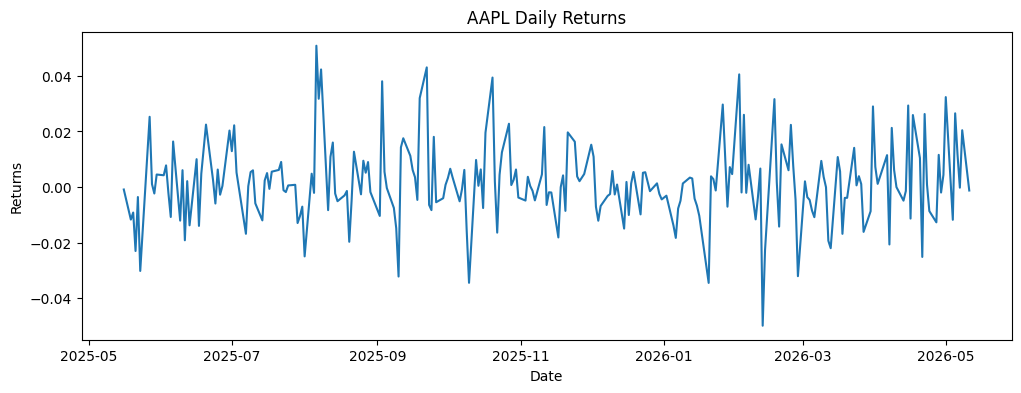

In [77]:
#Returns over time
plt.figure(figsize=(12,4))
plt.plot(history.index, history['Return'])
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

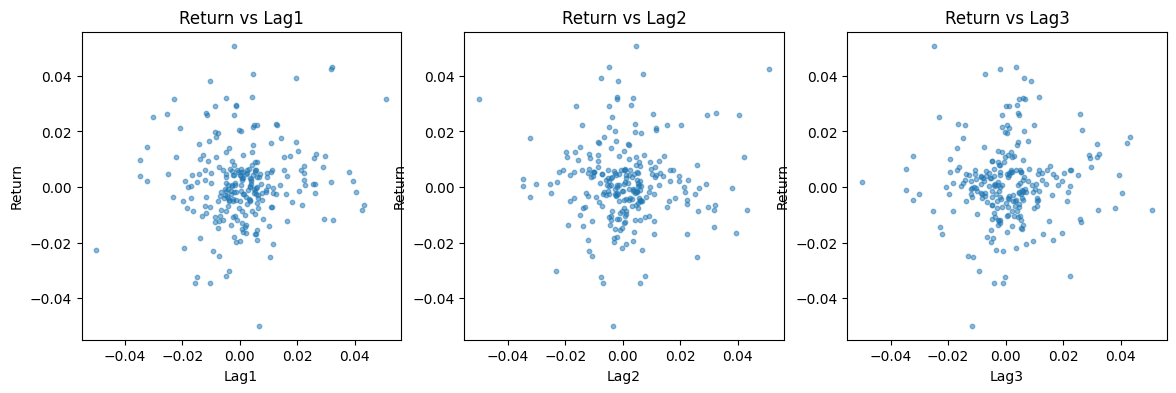

In [78]:
#Lag correlation scatter plot
fig, axes = plt.subplots(1,3,figsize=(14,4))

for i, lag in enumerate(['Lag1', 'Lag2', 'Lag3']):
    axes[i].scatter(history[lag], history['Return'], alpha=0.5, s=10)
    axes[i].set_xlabel(lag)
    axes[i].set_ylabel('Return')
    axes[i].set_title(f'Return vs {lag}')

plt.tight_layout
plt.show()

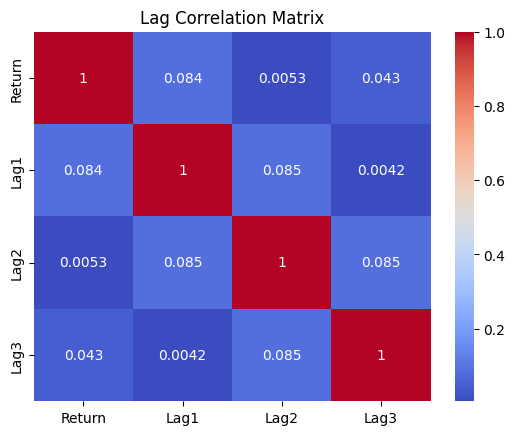

In [79]:
#correlation heatmap
corr = history[['Return','Lag1','Lag2','Lag3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Lag Correlation Matrix')
plt.show()

In [ ]:
#mean square error to average squared difference between predicted and actual returns
mse = np.mean((y_test - y_pred)**2)
print(f'MSE: {mse:.6f}')

MSE: 0.000218


In [81]:
#R^2 how much variance my model explains, from 0 to 1 the higher the better and if negative it is worse than just pred the mean
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f'R²: {r2:.4f}')


R²: -0.1027


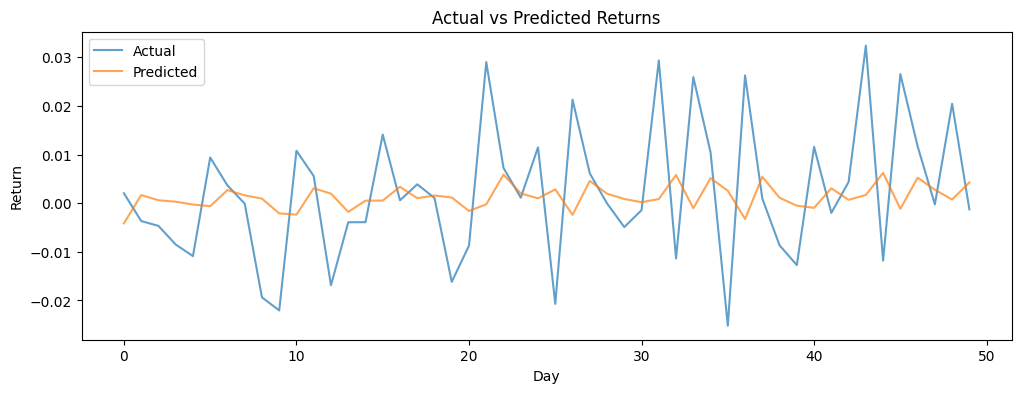

In [82]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()
